# Section 1: Introduction & System Selection

In this project, a stiff ordinary differential equation (ODE) is analyzed using both explicit and implicit numerical methods. Stiff ODEs arise in systems where processes occur on vastly different time scales, making standard explicit methods inefficient or unstable.

The system selected for this analysis is an RC electrical circuit with a fast transient response. The governing equation for the voltage across the capacitor is:

dV/dt = -(1/RC) * V + (1/RC) * V_source(t)

Using the given parameters:

R = 100 ohms  
C = 1e-9 farads  

we obtain:

1/(RC) = 1e7

so the equation becomes:

dV/dt = -1e7 * V + 1e7 * 5 * sin(t)

In this system, the circuit responds extremely quickly (on the order of 1e-7 seconds), while the input signal varies on a much slower time scale (on the order of seconds). This large disparity in time scales makes the system stiff.

This type of model is commonly used in high-speed electronics and signal processing, where rapid transient behavior must be accurately captured without numerical instability.

# Section 2: Demonstration of Stiffness

<ipython-input-8-7508aade9f2f>:5: RuntimeWarning: overflow encountered in double_scalars
  return -1e7 * V + 1e7 * 5 * np.sin(t)
<ipython-input-8-7508aade9f2f>:13: RuntimeWarning: invalid value encountered in double_scalars
  y[i+1] = y[i] + h * f(t[i], y[i])


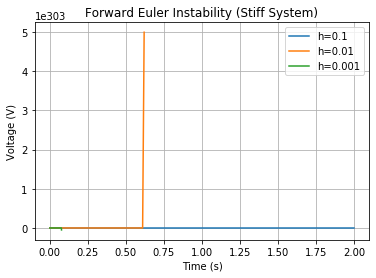

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, V):
    return -1e7 * V + 1e7 * 5 * np.sin(t)

def forward_euler(f, y0, t0, tf, h):
    t = np.arange(t0, tf + h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(len(t)-1):
        y[i+1] = y[i] + h * f(t[i], y[i])

    return t, y

h_values = [0.1, 0.01, 0.001]

for h in h_values:
    t, V = forward_euler(f, 0, 0, 2, h)
    plt.plot(t, V, label=f"h={h}")

plt.title("Forward Euler Instability (Stiff System)")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid()
plt.show()

The Forward Euler method performs poorly for this system due to stiffness. For reasonable step sizes such as \(h = 0.1\) and \(h = 0.01\), the solution becomes unstable and does not reflect the expected physical behavior.

This instability occurs because the system contains a very fast time scale associated with the term \(10^7 V\), which requires extremely small step sizes for explicit methods to remain stable. However, the forcing function varies slowly, meaning accuracy does not require such small steps.

This mismatch between stability requirements and accuracy requirements is the defining characteristic of a stiff system.

The stiffness of the system can be quantified by comparing the fastest and slowest time scales.

The fast time scale is determined by the coefficient in the ODE:

tau_fast = 1 / (1e7) = 1e-7 seconds

The slow time scale comes from the input function sin(t), which varies on the order of 1 second:

tau_slow ≈ 1 second

The stiffness ratio is therefore:

stiffness ratio = tau_slow / tau_fast = 1 / (1e-7) = 1e7

This extremely large ratio confirms that the system is highly stiff, meaning that explicit numerical methods will require extremely small step sizes for stability.

Such large stiffness ratios are common in high-speed electrical systems, where fast transient behavior coexists with slower input signals.

To maintain stability using the Forward Euler method, the step size h must be much smaller than the fastest time scale of the system.

Since the fast time scale is approximately 1e-7 seconds, the step size must satisfy:

h << 1e-7

This means h would need to be on the order of 1e-7 or smaller to produce a stable solution.

If we simulate the system over just 2 seconds, the number of required time steps would be:

number of steps ≈ 2 / (1e-7) = 2e7 steps

This corresponds to tens of millions of time steps, which is computationally impractical.

This demonstrates that Forward Euler is not suitable for stiff systems, as it requires extremely small step sizes for stability, even when such small steps are not needed for accuracy.

This motivates the use of implicit methods, such as Backward Euler, which can remain stable even for much larger step sizes.

# Section 3: Backward Euler Formulation

The Backward Euler method is an implicit method, meaning the next value appears on both sides of the equation.

The update formula is:

V_next = V_current + h * f(t_next, V_next)

Substituting the ODE:

V_next = V_current + h * (-1e7 * V_next + 1e7 * 5 * sin(t_next))

To solve for V_next, we define a residual function:

G(x) = x - V_current - h * (-1e7 * x + 1e7 * 5 * sin(t_next))

We then solve G(x) = 0 using Newton-Raphson.

The derivative is:

G'(x) = 1 + h * 1e7

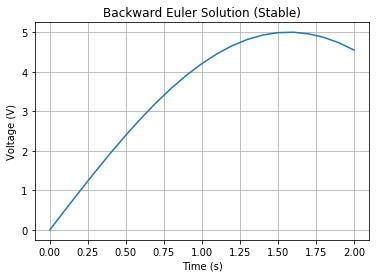

In [9]:
# Newton

def newton_solver(g, gprime, guess, tol=1e-6, max_iter=20):
    x = guess

    for _ in range(max_iter):
        x_new = x - g(x) / gprime(x)

        if abs(x_new - x) < tol:
            return x_new

        x = x_new

    return x

# Backward Euler

def backward_euler(y0, t0, tf, h):
    t = np.arange(t0, tf + h, h)
    y = np.zeros(len(t))
    y[0] = y0

    for i in range(len(t) - 1):
        tn1 = t[i+1]
        yn = y[i]

        def g(x):
            return x - yn - h * (-1e7 * x + 1e7 * 5 * np.sin(tn1))

        def gprime(x):
            return 1 + h * 1e7

        y[i+1] = newton_solver(g, gprime, yn)

    return t, y

t, V = backward_euler(0, 0, 2, 0.1)

plt.plot(t, V)
plt.title("Backward Euler Solution (Stable)")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.grid()
plt.show()

# Section 4: Results and Comparison

This section compares the behavior of Forward Euler and Backward Euler on the stiff RC circuit problem. Forward Euler was already shown to become unstable for reasonable step sizes. Backward Euler is now tested using the same step sizes to demonstrate the stability advantage of an implicit method.

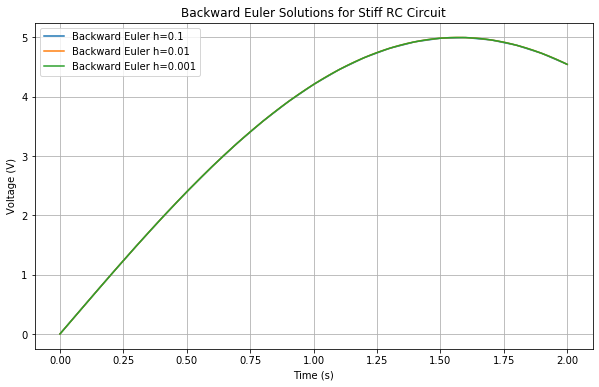

In [10]:
h_values = [0.1, 0.01, 0.001]

plt.figure(figsize=(10, 6))

for h in h_values:
    t, V = backward_euler(0, 0, 2, h)
    plt.plot(t, V, label=f"Backward Euler h={h}")

plt.title("Backward Euler Solutions for Stiff RC Circuit")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True)
plt.show()

Unlike Forward Euler, Backward Euler remains stable for all tested step sizes. The voltage solution stays bounded and follows the slowly varying input behavior instead of blowing up numerically.

This demonstrates the main advantage of implicit methods for stiff systems. Although Backward Euler requires solving an equation at every time step, it allows much larger step sizes than Forward Euler while still producing stable results.

<ipython-input-8-7508aade9f2f>:5: RuntimeWarning: overflow encountered in double_scalars
  return -1e7 * V + 1e7 * 5 * np.sin(t)
<ipython-input-8-7508aade9f2f>:13: RuntimeWarning: invalid value encountered in double_scalars
  y[i+1] = y[i] + h * f(t[i], y[i])
<ipython-input-12-0f22dd105cb1>:7: RuntimeWarning: invalid value encountered in greater
  V_fe_plot = np.where(np.abs(V_fe) > 100, np.nan, V_fe)


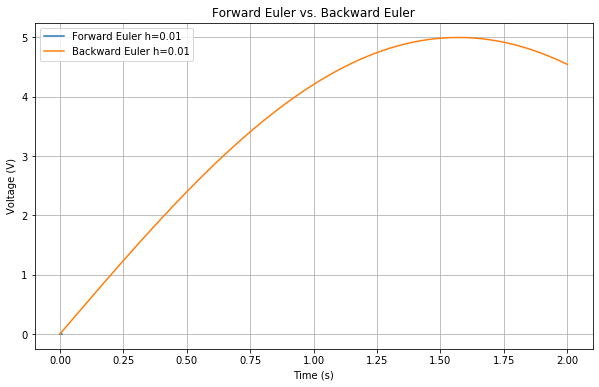

In [12]:
h = 0.01

t_fe, V_fe = forward_euler(f, 0, 0, 2, h)
t_be, V_be = backward_euler(0, 0, 2, h)

# Limit Forward Euler values so the plot remains readable
V_fe_plot = np.where(np.abs(V_fe) > 100, np.nan, V_fe)

plt.figure(figsize=(10, 6))
plt.plot(t_fe, V_fe_plot, label="Forward Euler h=0.01")
plt.plot(t_be, V_be, label="Backward Euler h=0.01")

plt.title("Forward Euler vs. Backward Euler")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True)
plt.show()

The comparison plot shows the difference between explicit and implicit time-stepping methods for a stiff ODE. Forward Euler becomes unstable and produces non-physical voltage values, while Backward Euler remains stable.

This occurs because Forward Euler evaluates the derivative using the current value, which makes it highly sensitive to the fast decay term in the ODE. Backward Euler evaluates the derivative using the next value, which gives it stronger stability properties for stiff systems.

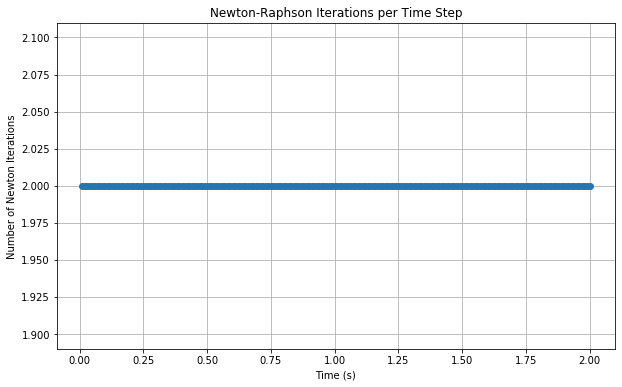

In [13]:
# New Newton

def newton_solver(g, gprime, guess, tol=1e-6, max_iter=20):
    x = guess

    for iteration in range(1, max_iter + 1):
        x_new = x - g(x) / gprime(x)

        if abs(x_new - x) < tol:
            return x_new, iteration

        x = x_new

    return x, max_iter

# New Backward Euler

def backward_euler(y0, t0, tf, h):
    t = np.arange(t0, tf + h, h)
    y = np.zeros(len(t))
    y[0] = y0

    iteration_counts = []

    for i in range(len(t) - 1):
        tn1 = t[i + 1]
        yn = y[i]

        def g(x):
            return x - yn - h * (-1e7 * x + 1e7 * 5 * np.sin(tn1))

        def gprime(x):
            return 1 + h * 1e7

        y_next, iterations = newton_solver(g, gprime, yn)

        y[i + 1] = y_next
        iteration_counts.append(iterations)

    return t, y, iteration_counts

t, V, iterations = backward_euler(0, 0, 2, h)

h = 0.01

t, V, iterations = backward_euler(0, 0, 2, h)

plt.figure(figsize=(10, 6))
plt.plot(t[1:], iterations, marker="o")
plt.title("Newton-Raphson Iterations per Time Step")
plt.xlabel("Time (s)")
plt.ylabel("Number of Newton Iterations")
plt.grid(True)
plt.show()

# Section 5: Newton-Raphson Convergence and Computational Cost

Because Backward Euler is implicit, each time step requires solving a nonlinear equation for the next voltage value. Newton-Raphson iteration is used to solve this equation.

Although the RC circuit equation is linear in V, Newton-Raphson is still implemented to demonstrate the general procedure used for implicit numerical methods.

The Newton-Raphson method converges quickly at each time step. Since the residual equation for this RC circuit is linear in V, the derivative is constant, allowing Newton-Raphson to converge in very few iterations.

This confirms that the implicit solve is computationally manageable for this problem.

Because the residual equation in this problem is linear, Newton-Raphson converges in very few iterations, typically in one or two steps.

In [16]:
h_values = [0.1, 0.01, 0.001]

cost_data = []

for h in h_values:
    t, V, iterations = backward_euler(0, 0, 2, h)

    steps = len(t) - 1
    avg_iterations = np.mean(iterations)
    total_iterations = np.sum(iterations)

    cost_data.append([h, steps, avg_iterations, total_iterations])

print(f"{'h':<10}{'Steps':<10}{'Avg Iter':<15}{'Total Iter':<15}")
for row in cost_data:
    print(f"{row[0]:<10}{row[1]:<10}{row[2]:<15.2f}{row[3]:<15}")


h         Steps     Avg Iter       Total Iter     
0.1       20        2.00           40             
0.01      200       2.00           400            
0.001     2000      2.00           4000           


As the step size decreases, the number of time steps increases. Smaller step sizes therefore increase the total computational cost, even though the average number of Newton iterations per step remains low.

Backward Euler is more expensive per step than Forward Euler because it requires solving an equation at every step. However, for stiff systems, this extra cost is justified because Backward Euler can remain stable with much larger step sizes.

# Section 6: Stability Discussion

The results clearly demonstrate the fundamental difference between explicit and implicit numerical methods when applied to stiff ODEs.

Forward Euler becomes unstable because its stability depends on resolving the fastest time scale in the system. In this problem, the term -1e7 * V introduces a very rapid decay, forcing the step size to be extremely small (on the order of 1e-7) for stability. For practical simulations over seconds, this leads to millions of time steps, making the method computationally infeasible.

Backward Euler avoids this restriction because it is unconditionally stable for linear problems of this form. By evaluating the derivative at the next time step, it effectively damps out the instability that causes Forward Euler to fail.

This demonstrates a key principle in numerical analysis: for stiff systems, stability constraints—not accuracy requirements—determine the step size when using explicit methods.

# Section 7: Conclusion

In this project, a stiff ordinary differential equation representing an RC circuit was solved using both Forward Euler and Backward Euler methods.

The results showed that Forward Euler is not suitable for stiff systems, as it becomes unstable unless extremely small step sizes are used. This leads to a very large number of time steps and high computational cost.

Backward Euler, despite requiring a nonlinear solve at each time step, provides stable and accurate solutions even for much larger step sizes. The Newton-Raphson method used to solve the implicit equation converged quickly, making the approach computationally feasible. 

Overall, this project demonstrates that implicit methods are essential for solving stiff ODEs efficiently. The tradeoff between computational cost per step and overall stability must be considered when selecting a numerical method for engineering applications. This tradeoff between per-step computational cost and overall stability is central to the numerical solution of stiff systems.